# TP — Implémentation et comparaison des méthodes d’optimisation — Exercice 1 : régression



## 1- Envoi  des fichiers

In [1]:
from google.colab import files
import os, glob, shutil
uploaded = files.upload()
os.makedirs("data", exist_ok=True)
for f in glob.glob("regression_nonlinear*.csv"): shutil.move(f, "data/regression_nonlinear.csv")
for f in glob.glob("regression_diabetes*.csv"):  shutil.move(f, "data/regression_diabetes.csv")
print(os.listdir("."), os.listdir("data"))

Saving regression_diabetes.csv to regression_diabetes.csv
Saving regression_nonlinear.csv to regression_nonlinear.csv
['.config', 'data', 'sample_data'] ['regression_diabetes.csv', 'regression_nonlinear.csv']


In [7]:
from google.colab import files

uploaded = files.upload()

Saving data_utils.py to data_utils.py
Saving ex1_regression.py to ex1_regression.py
Saving optim.py to optim.py
Saving plotting.py to plotting.py
Saving regression.py to regression.py
Saving verify_ex1.py to verify_ex1.py


## 2 — Installation des dépendances et versions utilisées


In [3]:
!pip install -q numpy pandas matplotlib scikit-learn

import sys, numpy, pandas, matplotlib, sklearn

print("Python      :", sys.version.split()[0])
print("numpy       :", numpy.__version__)
print("pandas      :", pandas.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.15
numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
scikit-learn: 1.6.1


##3 — Contrôle des fichiers de données

In [4]:
import pandas as pd
for name in ["regression_nonlinear", "regression_diabetes"]:
    df = pd.read_csv(f"data/{name}.csv")
    print(f"{name}: {df.shape[0]} lignes, {df.shape[1]-2} variables explicatives")
    print(df["split"].value_counts().to_dict(), "\n")

regression_nonlinear: 360 lignes, 2 variables explicatives
{'train': 216, 'val': 72, 'test': 72} 

regression_diabetes: 442 lignes, 10 variables explicatives
{'train': 265, 'test': 89, 'val': 88} 



## 4 — Vérifications automatiques du code


In [9]:
!python verify_ex1.py --data-dir data

[OK] GD / SGD : theta - eta g 
[OK] Momentum : v_t = mu v_{t-1} + g_t 
[OK] AdaGrad : s_t = s_{t-1} + g^2 
[OK] RMSprop : s_t = rho s_{t-1} + (1-rho) g^2 
[OK] Adam : correction de biais à t = 1 
[OK] Adam : correction de biais à t = 2 
[OK] [nonlinear/OLS] gradient complet vs différences finies (erreur relative max 7.4e-12)
[OK] [nonlinear/OLS] gradient mini-lot vs différences finies (erreur relative max 3.6e-11)
[OK] [nonlinear/OLS] solution de contrôle : gradient nul (||g|| = 1.3e-16)
[OK] [nonlinear/OLS] pas exact = pas numérique (1.0491 vs 1.0491)
[OK] [nonlinear/OLS] GD       réduit l'objectif (part de l'écart initial restante : -0.000)
[OK] [nonlinear/OLS] Momentum réduit l'objectif (part de l'écart initial restante : 0.001)
[OK] [nonlinear/OLS] AdaGrad  réduit l'objectif (part de l'écart initial restante : 0.000)
[OK] [nonlinear/OLS] RMSprop  réduit l'objectif (part de l'écart initial restante : 0.000)
[OK] [nonlinear/OLS] Adam     réduit l'objectif (part de l'écart initial res

## 5 — Test de fumée
Exécution rapide pour s'assurer que toute la chaîne fonctionne avant le lancement complet


In [10]:
!python ex1_regression.py --quick --data-dir data --out results/quick


=== nonlinear : 2 variables, effectifs {'train': 216, 'val': 72, 'test': 72}
  OLS: lambda=0 sigma=None J*=0.43949 (H inversible : True)
  Ridge: lambda=3.16 sigma=None J*=0.48573 (H inversible : True)
  Kernel: lambda=0.0001 sigma=0.6866543572027081 J*=0.01590 (H inversible : True)
  erreur relative max (différences finies, h=1e-5) : {'Kernel': '1.19e-08', 'OLS': '6.81e-10', 'Ridge': '5.78e-11'}
  OLS    GD       eta=       1  val RMSE=0.7312  test RMSE=0.8246
  OLS    GD+LS    eta=       —  val RMSE=0.7312  test RMSE=0.8243
  OLS    SGD      eta=       1  val RMSE=0.7220  test RMSE=0.8226
  OLS    Momentum eta=     0.1  val RMSE=0.7263  test RMSE=0.8261
  OLS    AdaGrad  eta=       1  val RMSE=0.7207  test RMSE=0.8217
  OLS    RMSprop  eta=       1  val RMSE=0.7193  test RMSE=0.8174
  OLS    Adam     eta=       1  val RMSE=0.7197  test RMSE=0.8156
  Ridge  GD       eta=       1  val RMSE=0.7408  test RMSE=0.8671
  Ridge  GD+LS    eta=       —  val RMSE=0.7499  test RMSE=0.8207
  Rid

##6 — Exécution complète


In [11]:
!python ex1_regression.py --data-dir data --out results/full


=== nonlinear : 2 variables, effectifs {'train': 216, 'val': 72, 'test': 72}
  OLS: lambda=0 sigma=None J*=0.43949 (H inversible : True)
  Ridge: lambda=3.16 sigma=None J*=0.48573 (H inversible : True)
  Kernel: lambda=0.0001 sigma=0.6866543572027081 J*=0.01590 (H inversible : True)
  erreur relative max (différences finies, h=1e-5) : {'Kernel': '1.19e-08', 'OLS': '6.81e-10', 'Ridge': '5.78e-11'}
  OLS    GD       eta=       1  val RMSE=0.7308  test RMSE=0.8232
  OLS    GD+LS    eta=       —  val RMSE=0.7324  test RMSE=0.8261
  OLS    SGD      eta=   0.316  val RMSE=0.7204  test RMSE=0.8196
  OLS    Momentum eta=     0.1  val RMSE=0.7185  test RMSE=0.8177
  OLS    AdaGrad  eta=    3.16  val RMSE=0.7172  test RMSE=0.8190
  OLS    RMSprop  eta=   0.316  val RMSE=0.7170  test RMSE=0.8164
  OLS    Adam     eta=   0.316  val RMSE=0.7173  test RMSE=0.8191
  Ridge  GD       eta=   0.316  val RMSE=0.7490  test RMSE=0.8191
  Ridge  GD+LS    eta=       —  val RMSE=0.7499  test RMSE=0.8207
  Rid

##7 — Jeu `nonlinear` : tableaux


In [12]:
from IPython.display import Markdown, Image, display
import glob
display(Markdown(open("results/full/nonlinear/tables.md", encoding="utf-8").read()))

## Jeu « nonlinear » : sept méthodes × trois modèles

Graines : [42, 123, 2024] (moyenne ± écart type, ddof = 1). Les colonnes RMSE/MSE/MAE sont dans l'unité d'origine de la cible ; la meilleure époque est choisie sur la RMSE de validation.

### Performances

| modèle | méthode | η | λ | σ | meilleure époque | RMSE val | MSE test | RMSE test | MAE test | R² test |
|---|---|---|---|---|---|---|---|---|---|---|
| OLS | GD | 1 | 0 | — | 1 | 0.7309 ± 0.0002 | 0.6788 ± 0.0011 | 0.8239 ± 0.0007 | 0.6948 ± 0.0005 | -0.0019 ± 0.0017 |
| OLS | GD+LS | — | 0 | — | 1 | 0.7315 ± 0.0008 | 0.6803 ± 0.0018 | 0.8248 ± 0.0011 | 0.6950 ± 0.0009 | -0.0041 ± 0.0027 |
| OLS | SGD | 0.316 | 0 | — | 243 | 0.7195 ± 0.0012 | 0.6686 ± 0.0045 | 0.8177 ± 0.0027 | 0.6775 ± 0.0052 | 0.0132 ± 0.0066 |
| OLS | Momentum | 0.1 | 0 | — | 243 | 0.7184 ± 0.0001 | 0.6664 ± 0.0021 | 0.8163 ± 0.0013 | 0.6778 ± 0.0057 | 0.0165 ± 0.0031 |
| OLS | AdaGrad | 3.16 | 0 | — | 174 | 0.7178 ± 0.0006 | 0.6678 ± 0.0037 | 0.8172 ± 0.0022 | 0.6718 ± 0.0064 | 0.0143 ± 0.0054 |
| OLS | RMSprop | 0.316 | 0 | — | 98 | 0.7178 ± 0.0007 | 0.6664 ± 0.0071 | 0.8163 ± 0.0043 | 0.6678 ± 0.0046 | 0.0165 ± 0.0105 |
| OLS | Adam | 0.316 | 0 | — | 82 | 0.7180 ± 0.0009 | 0.6710 ± 0.0073 | 0.8191 ± 0.0044 | 0.6737 ± 0.0030 | 0.0096 ± 0.0107 |
| Ridge | GD | 0.316 | 3.16 | — | 1 | 0.7422 ± 0.0059 | 0.6690 ± 0.0071 | 0.8179 ± 0.0043 | 0.7090 ± 0.0049 | 0.0127 ± 0.0105 |
| Ridge | GD+LS | — | 3.16 | — | 15 | 0.7499 ± 0.0001 | 0.6775 ± 0.0069 | 0.8231 ± 0.0042 | 0.7205 ± 0.0054 | 0.0000 ± 0.0102 |
| Ridge | SGD | 0.316 | 3.16 | — | 40 | 0.7223 ± 0.0004 | 0.6572 ± 0.0046 | 0.8107 ± 0.0028 | 0.6834 ± 0.0043 | 0.0300 ± 0.0067 |
| Ridge | Momentum | 0.1 | 3.16 | — | 61 | 0.7229 ± 0.0042 | 0.6607 ± 0.0037 | 0.8129 ± 0.0023 | 0.6883 ± 0.0066 | 0.0248 ± 0.0055 |
| Ridge | AdaGrad | 1 | 3.16 | — | 9 | 0.7302 ± 0.0062 | 0.6593 ± 0.0054 | 0.8120 ± 0.0033 | 0.6966 ± 0.0090 | 0.0270 ± 0.0080 |
| Ridge | RMSprop | 0.316 | 3.16 | — | 55 | 0.7207 ± 0.0017 | 0.6669 ± 0.0082 | 0.8166 ± 0.0050 | 0.6756 ± 0.0174 | 0.0157 ± 0.0121 |
| Ridge | Adam | 1 | 3.16 | — | 161 | 0.7215 ± 0.0036 | 0.6619 ± 0.0058 | 0.8136 ± 0.0036 | 0.6812 ± 0.0073 | 0.0231 ± 0.0086 |
| Ridge à noyau RBF | GD | 0.1 | 0.0001 | 0.687 | 2000 | 0.3191 ± 0.0002 | 0.1066 ± 0.0002 | 0.3265 ± 0.0003 | 0.2432 ± 0.0002 | 0.8427 ± 0.0003 |
| Ridge à noyau RBF | GD+LS | — | 0.0001 | 0.687 | 1999 | 0.2502 ± 0.0048 | 0.0659 ± 0.0032 | 0.2566 ± 0.0061 | 0.1886 ± 0.0046 | 0.9028 ± 0.0047 |
| Ridge à noyau RBF | SGD | 0.1 | 0.0001 | 0.687 | 298 | 0.3074 ± 0.0020 | 0.1094 ± 0.0028 | 0.3307 ± 0.0043 | 0.2484 ± 0.0044 | 0.8386 ± 0.0042 |
| Ridge à noyau RBF | Momentum | 0.1 | 0.0001 | 0.687 | 276 | 0.2006 ± 0.0017 | 0.0379 ± 0.0019 | 0.1946 ± 0.0048 | 0.1467 ± 0.0040 | 0.9441 ± 0.0028 |
| Ridge à noyau RBF | AdaGrad | 0.316 | 0.0001 | 0.687 | 285 | 0.2648 ± 0.0064 | 0.0859 ± 0.0057 | 0.2929 ± 0.0097 | 0.2158 ± 0.0096 | 0.8733 ± 0.0084 |
| Ridge à noyau RBF | RMSprop | 0.01 | 0.0001 | 0.687 | 282 | 0.2472 ± 0.0038 | 0.0720 ± 0.0019 | 0.2683 ± 0.0036 | 0.1979 ± 0.0034 | 0.8937 ± 0.0028 |
| Ridge à noyau RBF | Adam | 0.1 | 0.0001 | 0.687 | 258 | 0.1852 ± 0.0105 | 0.0303 ± 0.0041 | 0.1739 ± 0.0120 | 0.1372 ± 0.0118 | 0.9552 ± 0.0061 |

### Coûts de calcul

| modèle | méthode | époques exécutées | mises à jour | appels gradient | échantillons-gradient | appels perte | produits H·g | temps (s) | J au meilleur itéré | J* (contrôle) |
|---|---|---|---|---|---|---|---|---|---|---|
| OLS | GD | 11 | 11 | 11 | 2376 | 0 | 0 | 0.0004 ± 0.0000 | 0.43981 | 0.43949 |
| OLS | GD+LS | 11 | 11 | 11 | 2304 | 0 | 11 | 0.0005 ± 0.0001 | 0.43973 | 0.43949 |
| OLS | SGD | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0606 ± 0.0007 | 0.45068 | 0.43949 |
| OLS | Momentum | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0397 ± 0.0018 | 0.45391 | 0.43949 |
| OLS | AdaGrad | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0442 ± 0.0013 | 0.45895 | 0.43949 |
| OLS | RMSprop | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0605 ± 0.0082 | 0.46435 | 0.43949 |
| OLS | Adam | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0588 ± 0.0018 | 0.45897 | 0.43949 |
| Ridge | GD | 67 | 67 | 67 | 14472 | 0 | 0 | 0.0012 ± 0.0001 | 0.49738 | 0.48573 |
| Ridge | GD+LS | 22 | 22 | 22 | 4824 | 0 | 22 | 0.0006 ± 0.0000 | 0.48668 | 0.48573 |
| Ridge | SGD | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0440 ± 0.0053 | 0.56951 | 0.48573 |
| Ridge | Momentum | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0416 ± 0.0025 | 0.57188 | 0.48573 |
| Ridge | AdaGrad | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0533 ± 0.0058 | 0.52417 | 0.48573 |
| Ridge | RMSprop | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0507 ± 0.0037 | 0.64706 | 0.48573 |
| Ridge | Adam | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0645 ± 0.0063 | 0.60074 | 0.48573 |
| Ridge à noyau RBF | GD | 2000 | 2000 | 2000 | 432000 | 0 | 0 | 0.1139 ± 0.0110 | 0.05861 | 0.01590 |
| Ridge à noyau RBF | GD+LS | 2000 | 2000 | 2000 | 432000 | 0 | 2000 | 0.1697 ± 0.0038 | 0.03272 | 0.01590 |
| Ridge à noyau RBF | SGD | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0852 ± 0.0248 | 0.05999 | 0.01590 |
| Ridge à noyau RBF | Momentum | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0742 ± 0.0059 | 0.02530 | 0.01590 |
| Ridge à noyau RBF | AdaGrad | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0803 ± 0.0012 | 0.04365 | 0.01590 |
| Ridge à noyau RBF | RMSprop | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.0987 ± 0.0049 | 0.03554 | 0.01590 |
| Ridge à noyau RBF | Adam | 300 | 2100 | 2100 | 64800 | 0 | 0 | 0.1007 ± 0.0017 | 0.02426 | 0.01590 |

### Solutions de contrôle (résolution linéaire, non utilisées pour entraîner)

| model | val_rmse | test_mse | test_rmse | test_mae | test_r2 | J_star |
|---|---|---|---|---|---|---|
| OLS | 0.7346 | 0.6842 | 0.8272 | 0.6983 | -0.0098 | 0.4395 |
| Ridge | 0.7499 | 0.6735 | 0.8207 | 0.7174 | 0.0059 | 0.4857 |
| Ridge à noyau RBF | 0.1502 | 0.0183 | 0.1352 | 0.1069 | 0.9730 | 0.0159 |

### Vérification des gradients (erreur relative max, h = 1e-5)

| model | lot | erreur_relative |
|---|---|---|
| Kernel | lot complet | 1.19e-08 |
| Kernel | mini-lot 32 | 3.98e-10 |
| OLS | lot complet | 6.81e-10 |
| OLS | mini-lot 32 | 7.31e-12 |
| Ridge | lot complet | 5.78e-11 |
| Ridge | mini-lot 32 | 7.31e-12 |


## 8 — Jeu `nonlinear` : figures


results/full/nonlinear/figures/nonlinear_Kernel_courbes.png


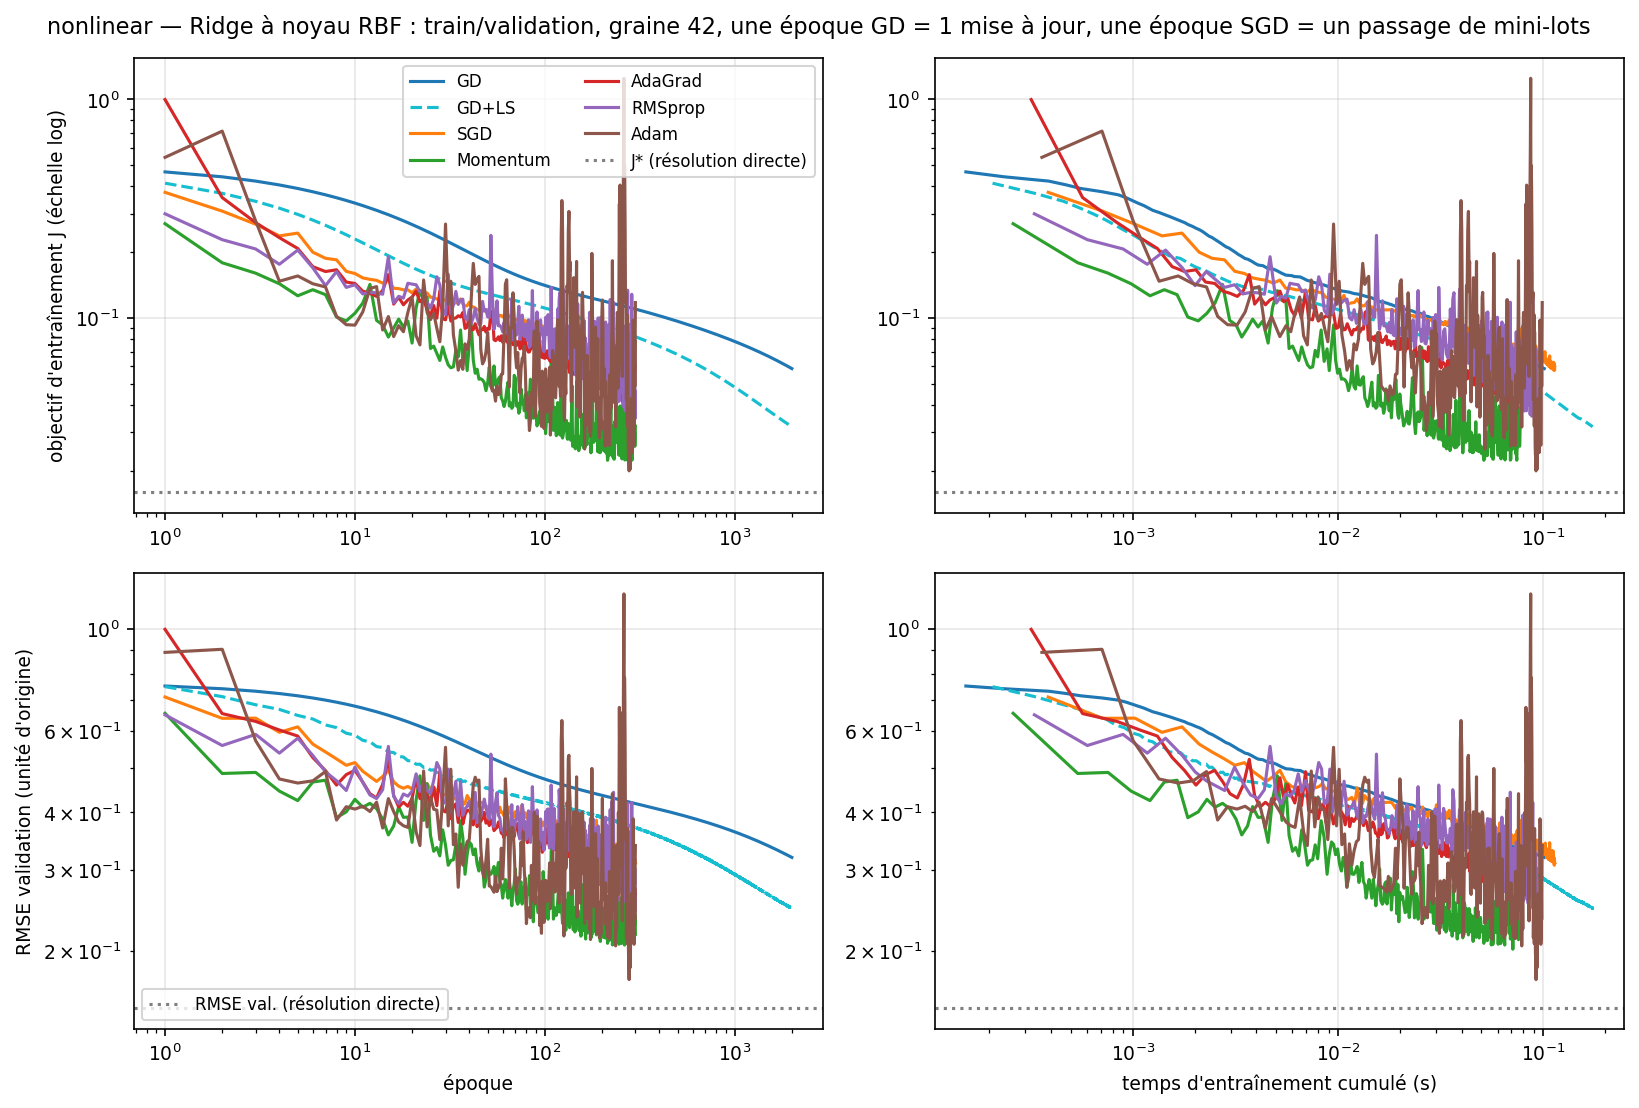

results/full/nonlinear/figures/nonlinear_OLS_courbes.png


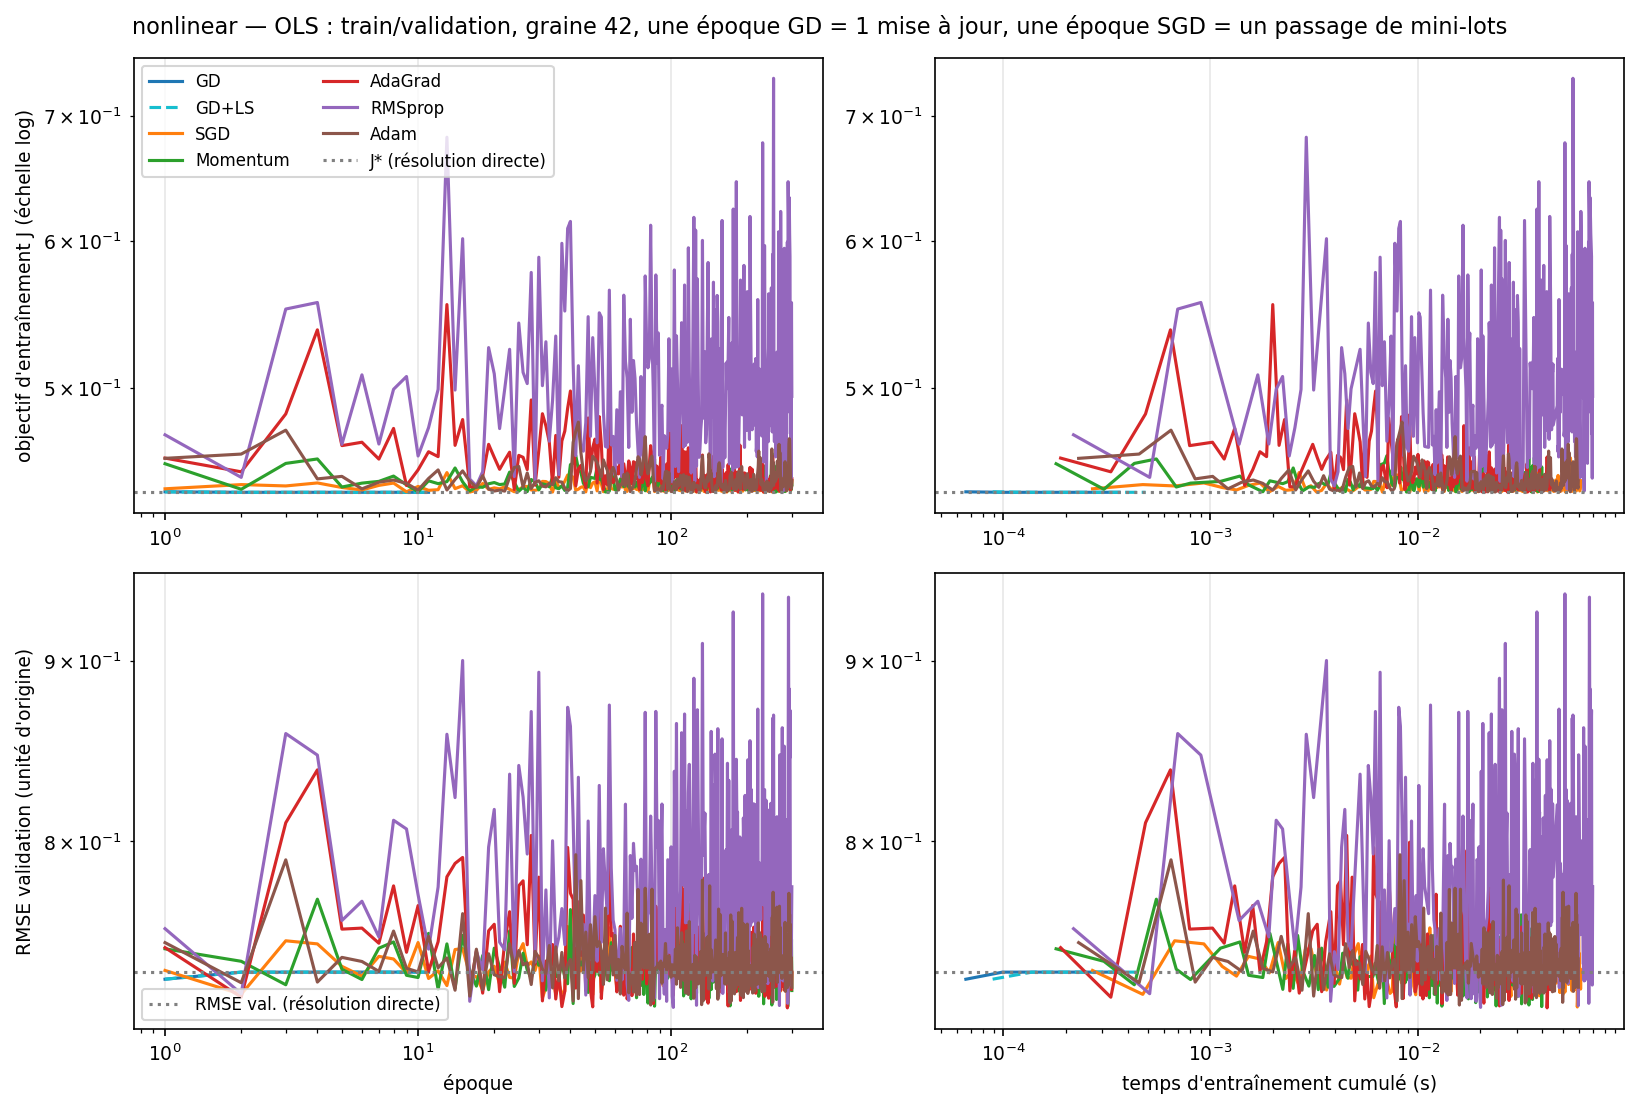

results/full/nonlinear/figures/nonlinear_Ridge_courbes.png


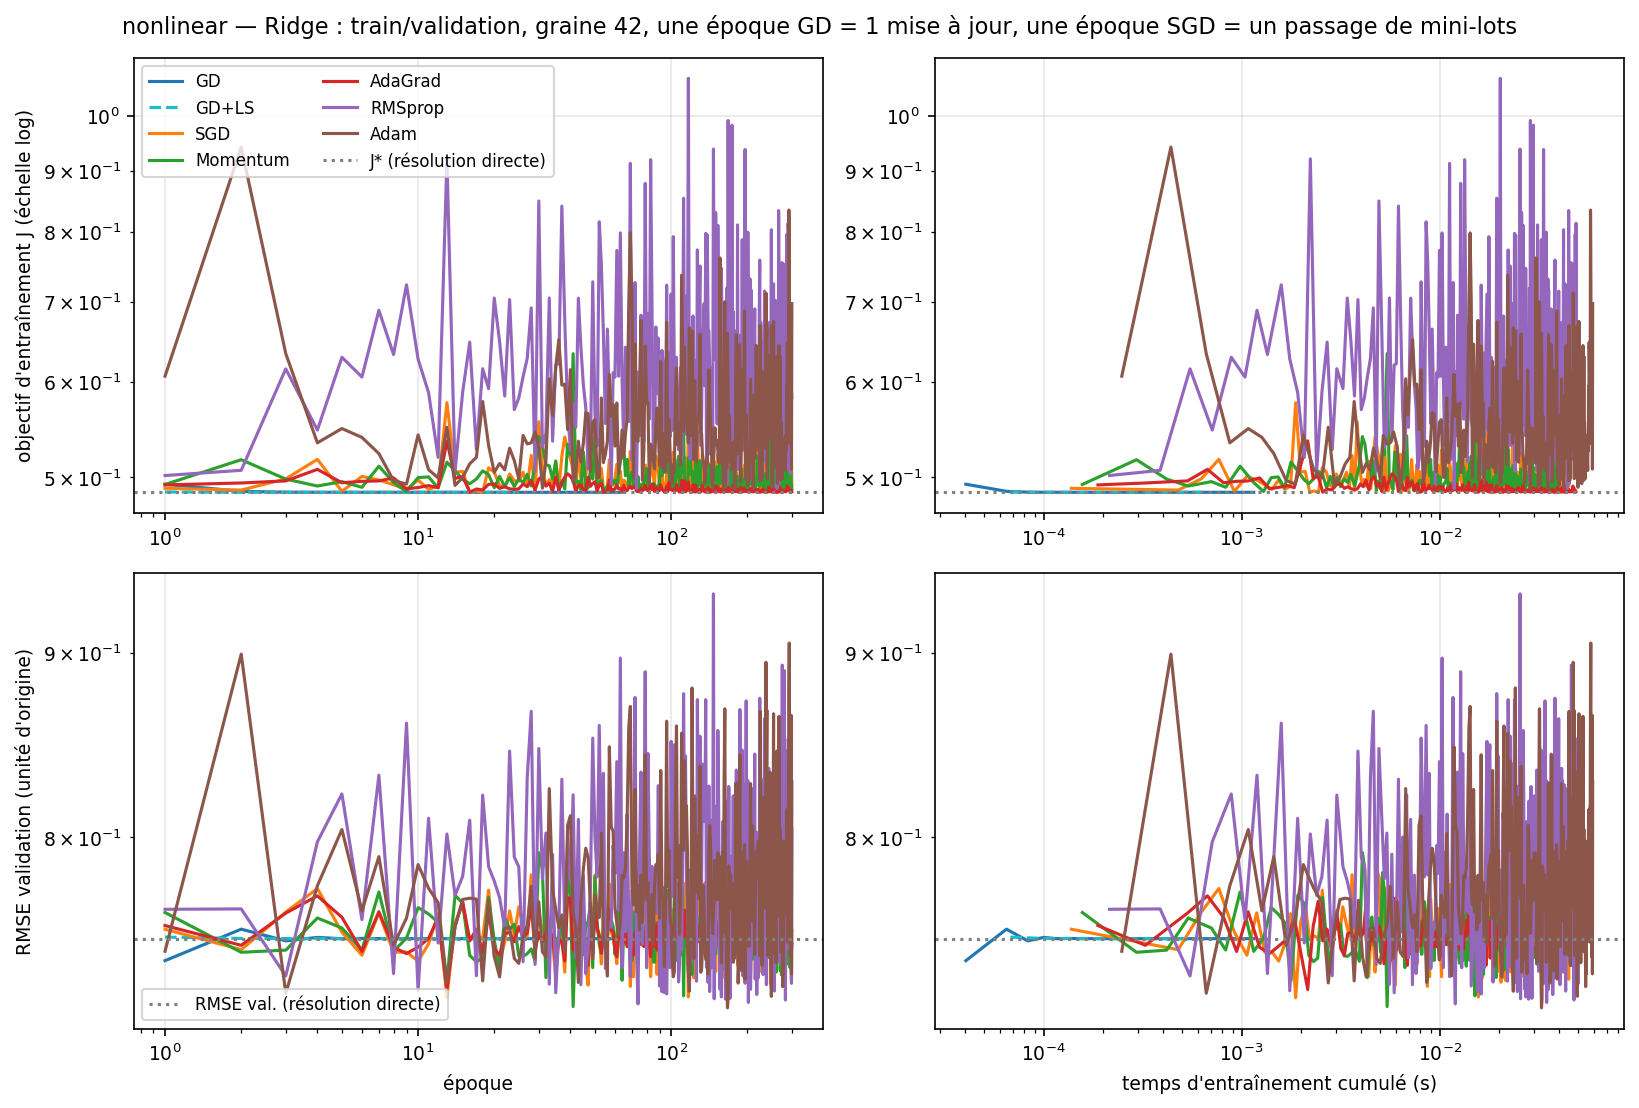

results/full/nonlinear/figures/nonlinear_predit_vs_reel.png


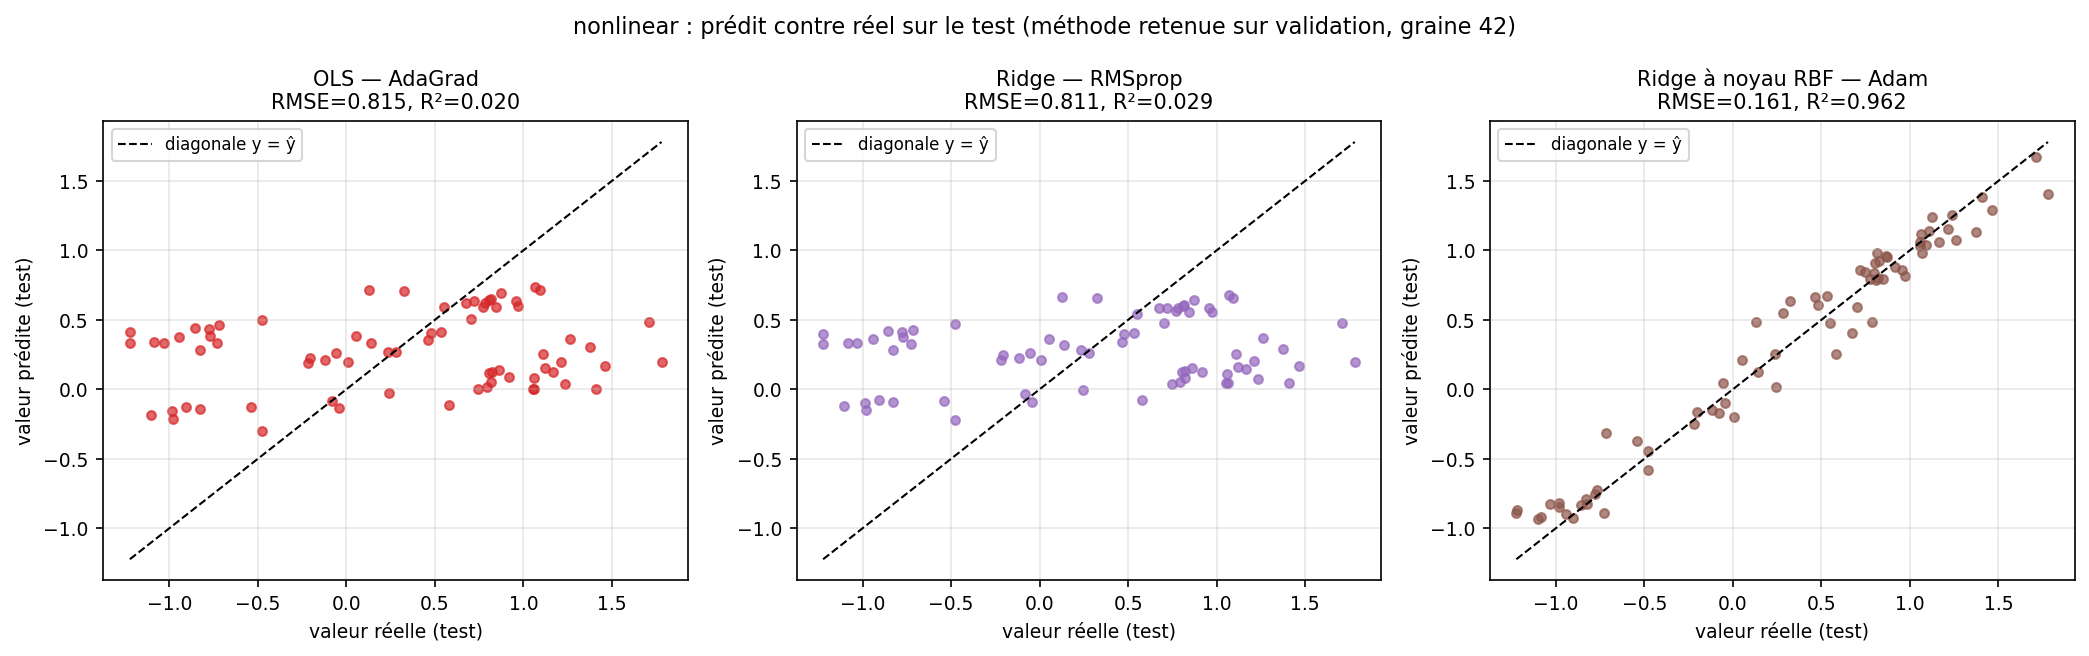

results/full/nonlinear/figures/nonlinear_residus.png


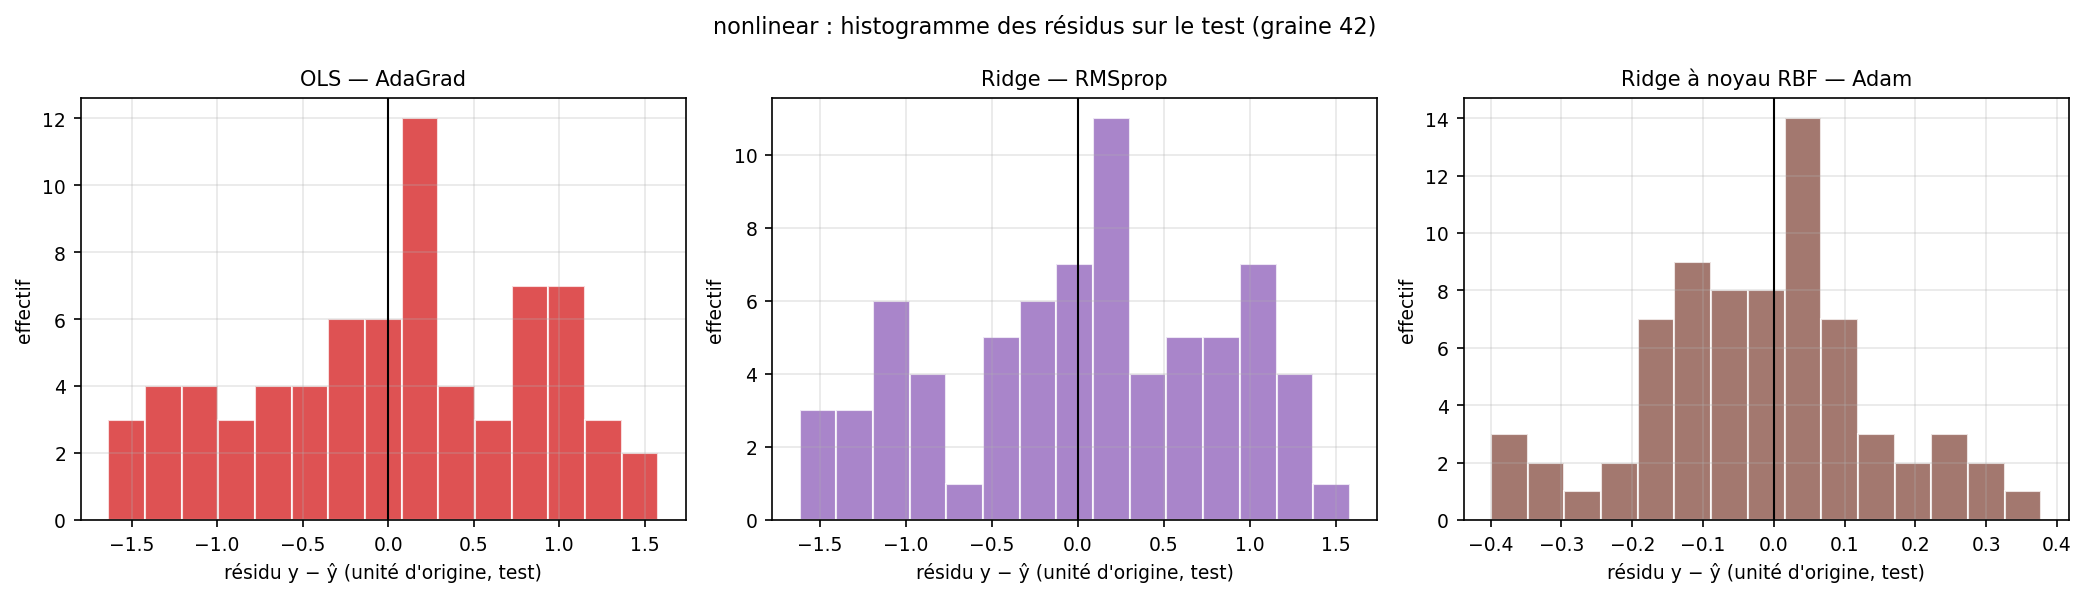

results/full/nonlinear/figures/nonlinear_rmse_test_par_methode.png


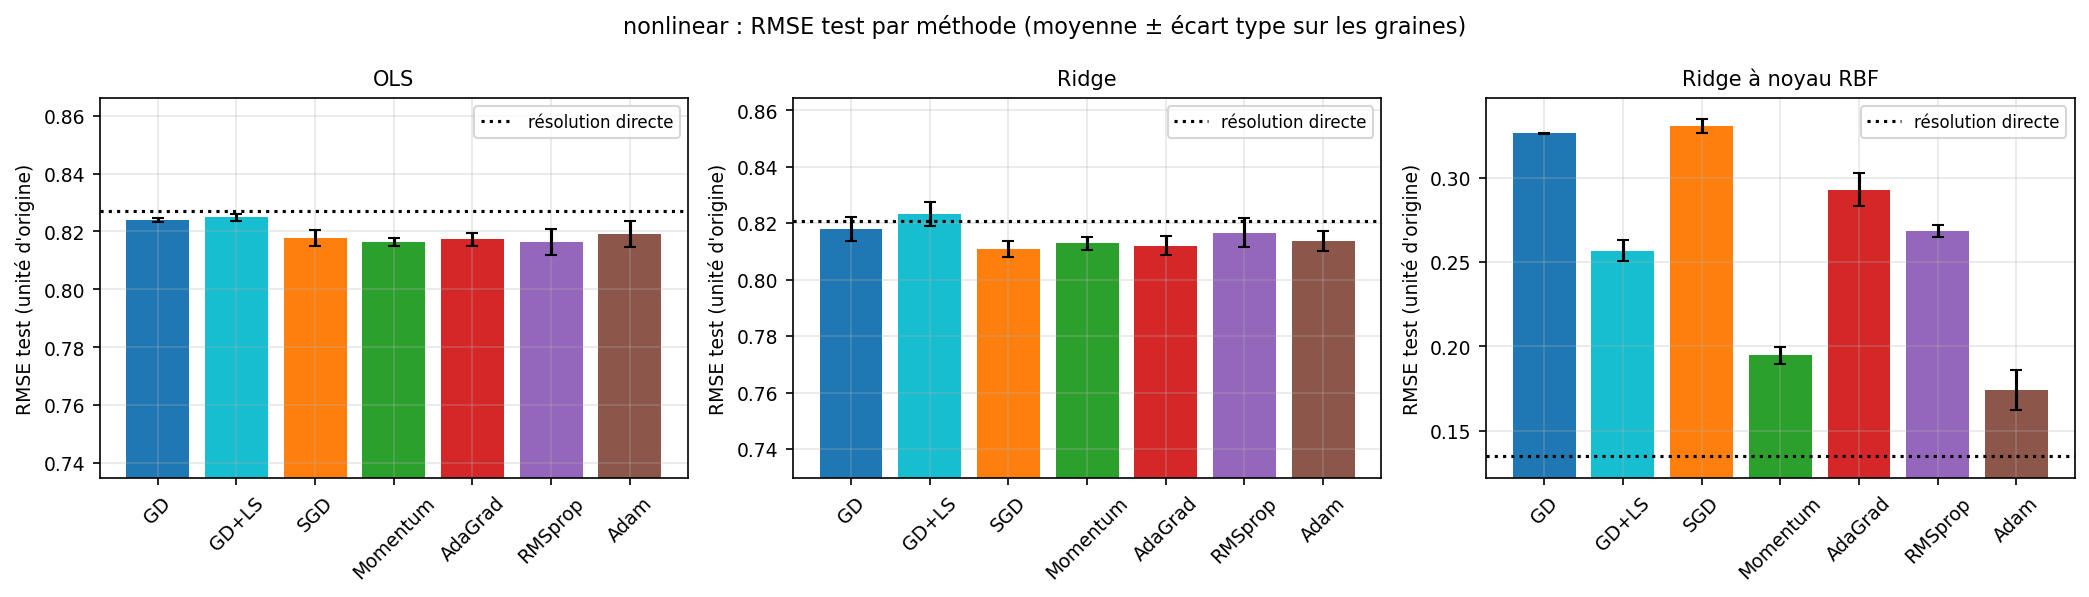

results/full/nonlinear/figures/nonlinear_surface.png


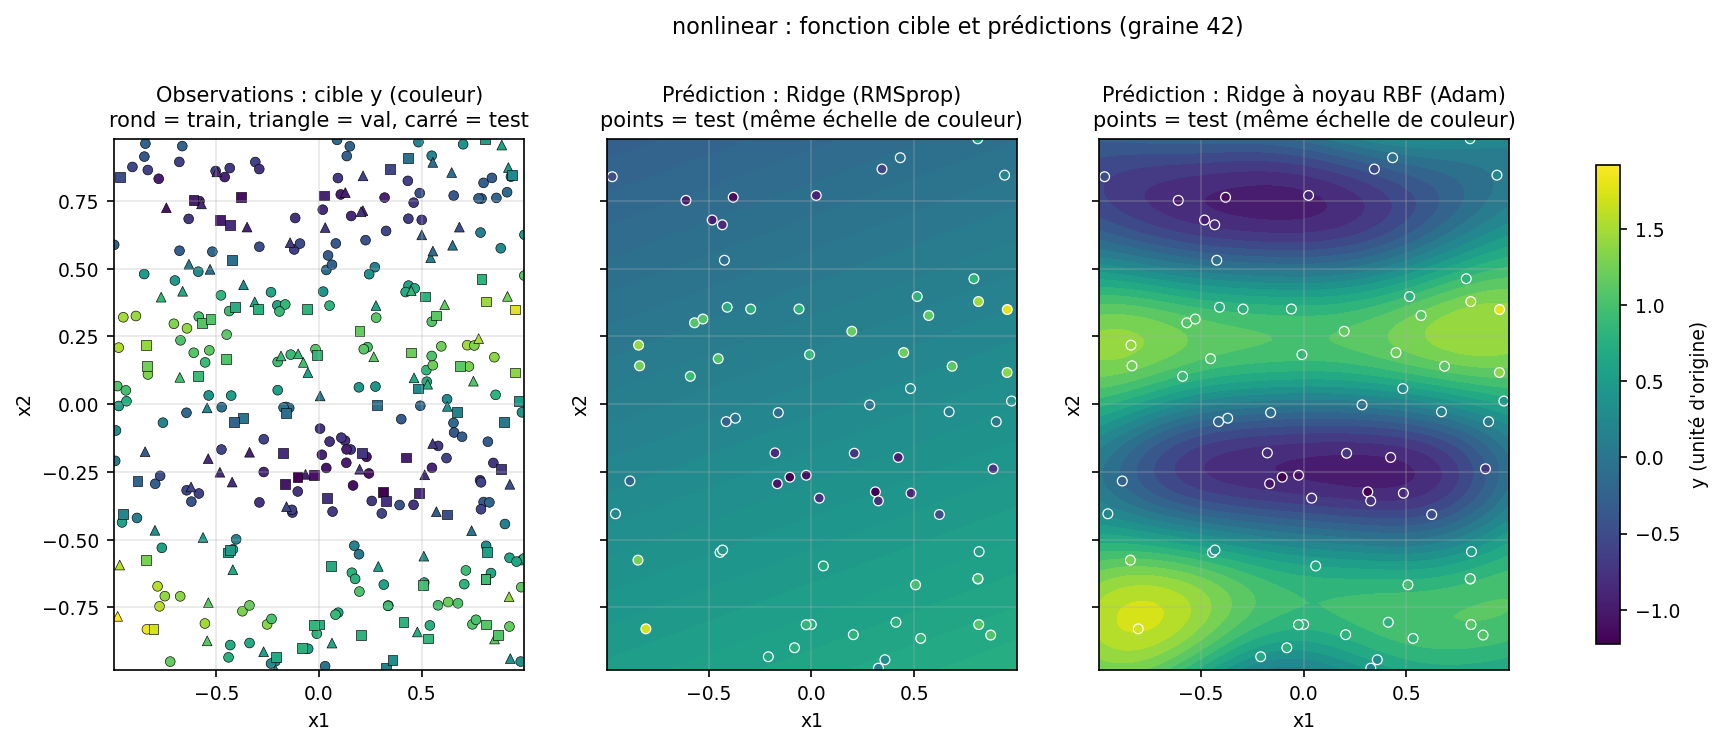

In [13]:
for f in sorted(glob.glob("results/full/nonlinear/figures/*.png")):
    print(f); display(Image(f))

## 9 — Jeu `diabetes` : tableaux


In [14]:
display(Markdown(open("results/full/diabetes/tables.md", encoding="utf-8").read()))

## Jeu « diabetes » : sept méthodes × trois modèles

Graines : [42, 123, 2024] (moyenne ± écart type, ddof = 1). Les colonnes RMSE/MSE/MAE sont dans l'unité d'origine de la cible ; la meilleure époque est choisie sur la RMSE de validation.

### Performances

| modèle | méthode | η | λ | σ | meilleure époque | RMSE val | MSE test | RMSE test | MAE test | R² test |
|---|---|---|---|---|---|---|---|---|---|---|
| OLS | GD | 0.316 | 0 | — | 7 | 58.4470 ± 0.0879 | 3534.4821 ± 88.8488 | 59.4484 ± 0.7494 | 48.4144 ± 0.5984 | 0.3972 ± 0.0152 |
| OLS | GD+LS | — | 0 | — | 4 | 58.3228 ± 0.1482 | 3469.7300 ± 122.9783 | 58.8982 ± 1.0441 | 47.6804 ± 0.7985 | 0.4082 ± 0.0210 |
| OLS | SGD | 0.1 | 0 | — | 53 | 58.3257 ± 0.4771 | 3404.5792 ± 50.3724 | 58.3477 ± 0.4324 | 47.1745 ± 0.2284 | 0.4193 ± 0.0086 |
| OLS | Momentum | 0.1 | 0 | — | 211 | 58.1585 ± 0.3086 | 3554.8532 ± 96.0371 | 59.6190 ± 0.8062 | 48.6556 ± 0.9954 | 0.3937 ± 0.0164 |
| OLS | AdaGrad | 10 | 0 | — | 54 | 58.5042 ± 0.3307 | 3829.4336 ± 355.5709 | 61.8377 ± 2.8815 | 49.7618 ± 1.8835 | 0.3469 ± 0.0606 |
| OLS | RMSprop | 0.01 | 0 | — | 6 | 58.3310 ± 0.4083 | 3516.6219 ± 102.7555 | 59.2969 ± 0.8680 | 48.0938 ± 0.9402 | 0.4002 ± 0.0175 |
| OLS | Adam | 0.316 | 0 | — | 213 | 57.9802 ± 0.4402 | 3578.6729 ± 104.8898 | 59.8178 ± 0.8733 | 47.7154 ± 0.7675 | 0.3896 ± 0.0179 |
| Ridge | GD | 0.316 | 1 | — | 27 | 59.2453 ± 0.0544 | 3811.5044 ± 28.8754 | 61.7371 ± 0.2336 | 49.9754 ± 0.1647 | 0.3499 ± 0.0049 |
| Ridge | GD+LS | — | 1 | — | 40 | 59.2835 ± 0.0266 | 3805.2323 ± 17.8361 | 61.6865 ± 0.1445 | 49.8628 ± 0.0470 | 0.3510 ± 0.0030 |
| Ridge | SGD | 0.316 | 1 | — | 122 | 56.7011 ± 0.0797 | 3684.2555 ± 30.7122 | 60.6977 ± 0.2529 | 49.0591 ± 0.6196 | 0.3716 ± 0.0052 |
| Ridge | Momentum | 0.1 | 1 | — | 189 | 56.7835 ± 0.3138 | 3742.6072 ± 160.3912 | 61.1675 ± 1.3076 | 48.7458 ± 1.1913 | 0.3617 ± 0.0274 |
| Ridge | AdaGrad | 10 | 1 | — | 116 | 57.1001 ± 0.1143 | 3704.3561 ± 365.8204 | 60.8135 ± 3.0175 | 48.6693 ± 1.7950 | 0.3682 ± 0.0624 |
| Ridge | RMSprop | 0.1 | 1 | — | 134 | 56.7130 ± 0.2862 | 3704.5701 ± 320.0666 | 60.8277 ± 2.6141 | 49.3699 ± 2.0399 | 0.3682 ± 0.0546 |
| Ridge | Adam | 0.316 | 1 | — | 236 | 56.8489 ± 0.3929 | 3697.0608 ± 232.1136 | 60.7838 ± 1.8958 | 48.8093 ± 1.8096 | 0.3694 ± 0.0396 |
| Ridge à noyau RBF | GD | 0.0316 | 0.0316 | 2.91 | 374 | 57.5782 ± 0.0025 | 3699.5279 ± 1.9136 | 60.8237 ± 0.0157 | 49.0513 ± 0.0031 | 0.3690 ± 0.0003 |
| Ridge à noyau RBF | GD+LS | — | 0.0316 | 2.91 | 152 | 57.5621 ± 0.0068 | 3708.7906 ± 1.3378 | 60.8998 ± 0.0110 | 49.0809 ± 0.0131 | 0.3674 ± 0.0002 |
| Ridge à noyau RBF | SGD | 0.0316 | 0.0316 | 2.91 | 97 | 57.0782 ± 0.0523 | 3795.6504 ± 63.7986 | 61.6074 ± 0.5190 | 49.2035 ± 0.2522 | 0.3526 ± 0.0109 |
| Ridge à noyau RBF | Momentum | 0.01 | 0.0316 | 2.91 | 86 | 56.9482 ± 0.1157 | 3766.3838 ± 35.9013 | 61.3704 ± 0.2923 | 48.9704 ± 0.1971 | 0.3576 ± 0.0061 |
| Ridge à noyau RBF | AdaGrad | 0.316 | 0.0316 | 2.91 | 218 | 57.1344 ± 0.1018 | 3831.0505 ± 32.6502 | 61.8951 ± 0.2641 | 49.3553 ± 0.0750 | 0.3466 ± 0.0056 |
| Ridge à noyau RBF | RMSprop | 0.01 | 0.0316 | 2.91 | 212 | 57.0850 ± 0.1991 | 3806.1770 ± 84.5157 | 61.6917 ± 0.6860 | 49.1465 ± 0.4298 | 0.3508 ± 0.0144 |
| Ridge à noyau RBF | Adam | 1 | 0.0316 | 2.91 | 45 | 56.5842 ± 0.5242 | 3705.7189 ± 133.1444 | 60.8681 ± 1.0900 | 48.8659 ± 0.8551 | 0.3680 ± 0.0227 |

### Coûts de calcul

| modèle | méthode | époques exécutées | mises à jour | appels gradient | échantillons-gradient | appels perte | produits H·g | temps (s) | J au meilleur itéré | J* (contrôle) |
|---|---|---|---|---|---|---|---|---|---|---|
| OLS | GD | 2000 | 2000 | 2000 | 530000 | 0 | 0 | 0.0415 ± 0.0026 | 0.21504 | 0.20944 |
| OLS | GD+LS | 2000 | 2000 | 2000 | 530000 | 0 | 2000 | 0.0526 ± 0.0013 | 0.21717 | 0.20944 |
| OLS | SGD | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0463 ± 0.0002 | 0.21498 | 0.20944 |
| OLS | Momentum | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0499 ± 0.0005 | 0.22160 | 0.20944 |
| OLS | AdaGrad | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0616 ± 0.0094 | 0.22720 | 0.20944 |
| OLS | RMSprop | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0728 ± 0.0058 | 0.21591 | 0.20944 |
| OLS | Adam | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0798 ± 0.0046 | 0.23035 | 0.20944 |
| Ridge | GD | 68 | 68 | 68 | 18108 | 0 | 0 | 0.0026 ± 0.0002 | 0.30098 | 0.30032 |
| Ridge | GD+LS | 58 | 58 | 58 | 15458 | 0 | 58 | 0.0019 ± 0.0002 | 0.30038 | 0.30032 |
| Ridge | SGD | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0873 ± 0.0074 | 0.34156 | 0.30032 |
| Ridge | Momentum | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0934 ± 0.0023 | 0.34338 | 0.30032 |
| Ridge | AdaGrad | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0572 ± 0.0008 | 0.33304 | 0.30032 |
| Ridge | RMSprop | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0627 ± 0.0009 | 0.34471 | 0.30032 |
| Ridge | Adam | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.0855 ± 0.0061 | 0.35281 | 0.30032 |
| Ridge à noyau RBF | GD | 2000 | 2000 | 2000 | 530000 | 0 | 0 | 0.0998 ± 0.0066 | 0.29546 | 0.29296 |
| Ridge à noyau RBF | GD+LS | 2000 | 2000 | 2000 | 530000 | 0 | 2000 | 0.1587 ± 0.0033 | 0.29560 | 0.29296 |
| Ridge à noyau RBF | SGD | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.1062 ± 0.0083 | 0.29762 | 0.29296 |
| Ridge à noyau RBF | Momentum | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.1181 ± 0.0080 | 0.29692 | 0.29296 |
| Ridge à noyau RBF | AdaGrad | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.1791 ± 0.0021 | 0.29998 | 0.29296 |
| Ridge à noyau RBF | RMSprop | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.1321 ± 0.0094 | 0.29844 | 0.29296 |
| Ridge à noyau RBF | Adam | 300 | 2700 | 2700 | 79500 | 0 | 0 | 0.1499 ± 0.0110 | 0.32416 | 0.29296 |

### Solutions de contrôle (résolution linéaire, non utilisées pour entraîner)

| model | val_rmse | test_mse | test_rmse | test_mae | test_r2 | J_star |
|---|---|---|---|---|---|---|
| OLS | 59.8306 | 3528.4317 | 59.4006 | 48.1776 | 0.3982 | 0.2094 |
| Ridge | 59.2989 | 3794.9346 | 61.6030 | 49.8357 | 0.3527 | 0.3003 |
| Ridge à noyau RBF | 57.6141 | 3685.6402 | 60.7095 | 48.8527 | 0.3714 | 0.2930 |

### Vérification des gradients (erreur relative max, h = 1e-5)

| model | lot | erreur_relative |
|---|---|---|
| Kernel | lot complet | 4.86e-11 |
| Kernel | mini-lot 32 | 2.58e-11 |
| OLS | lot complet | 5.78e-11 |
| OLS | mini-lot 32 | 1.50e-10 |
| Ridge | lot complet | 1.07e-10 |
| Ridge | mini-lot 32 | 2.63e-11 |


## 10— Jeu `diabetes` : figures


results/full/diabetes/figures/diabetes_Kernel_courbes.png


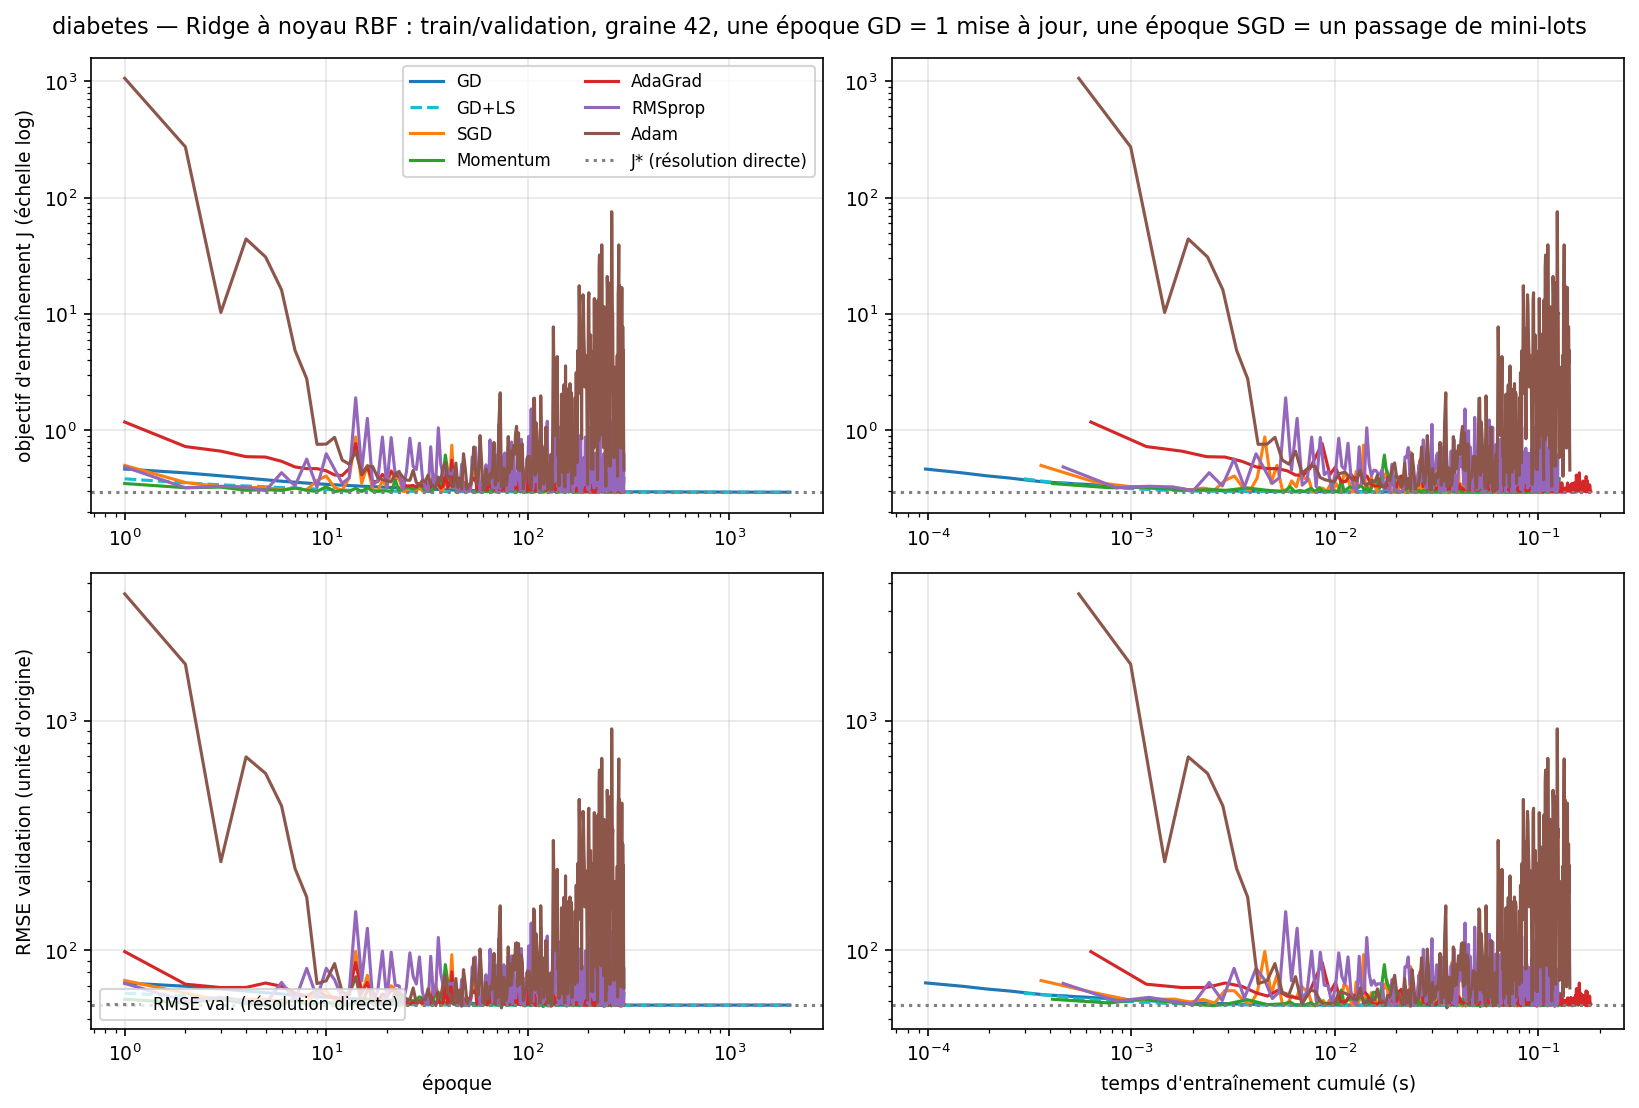

results/full/diabetes/figures/diabetes_OLS_courbes.png


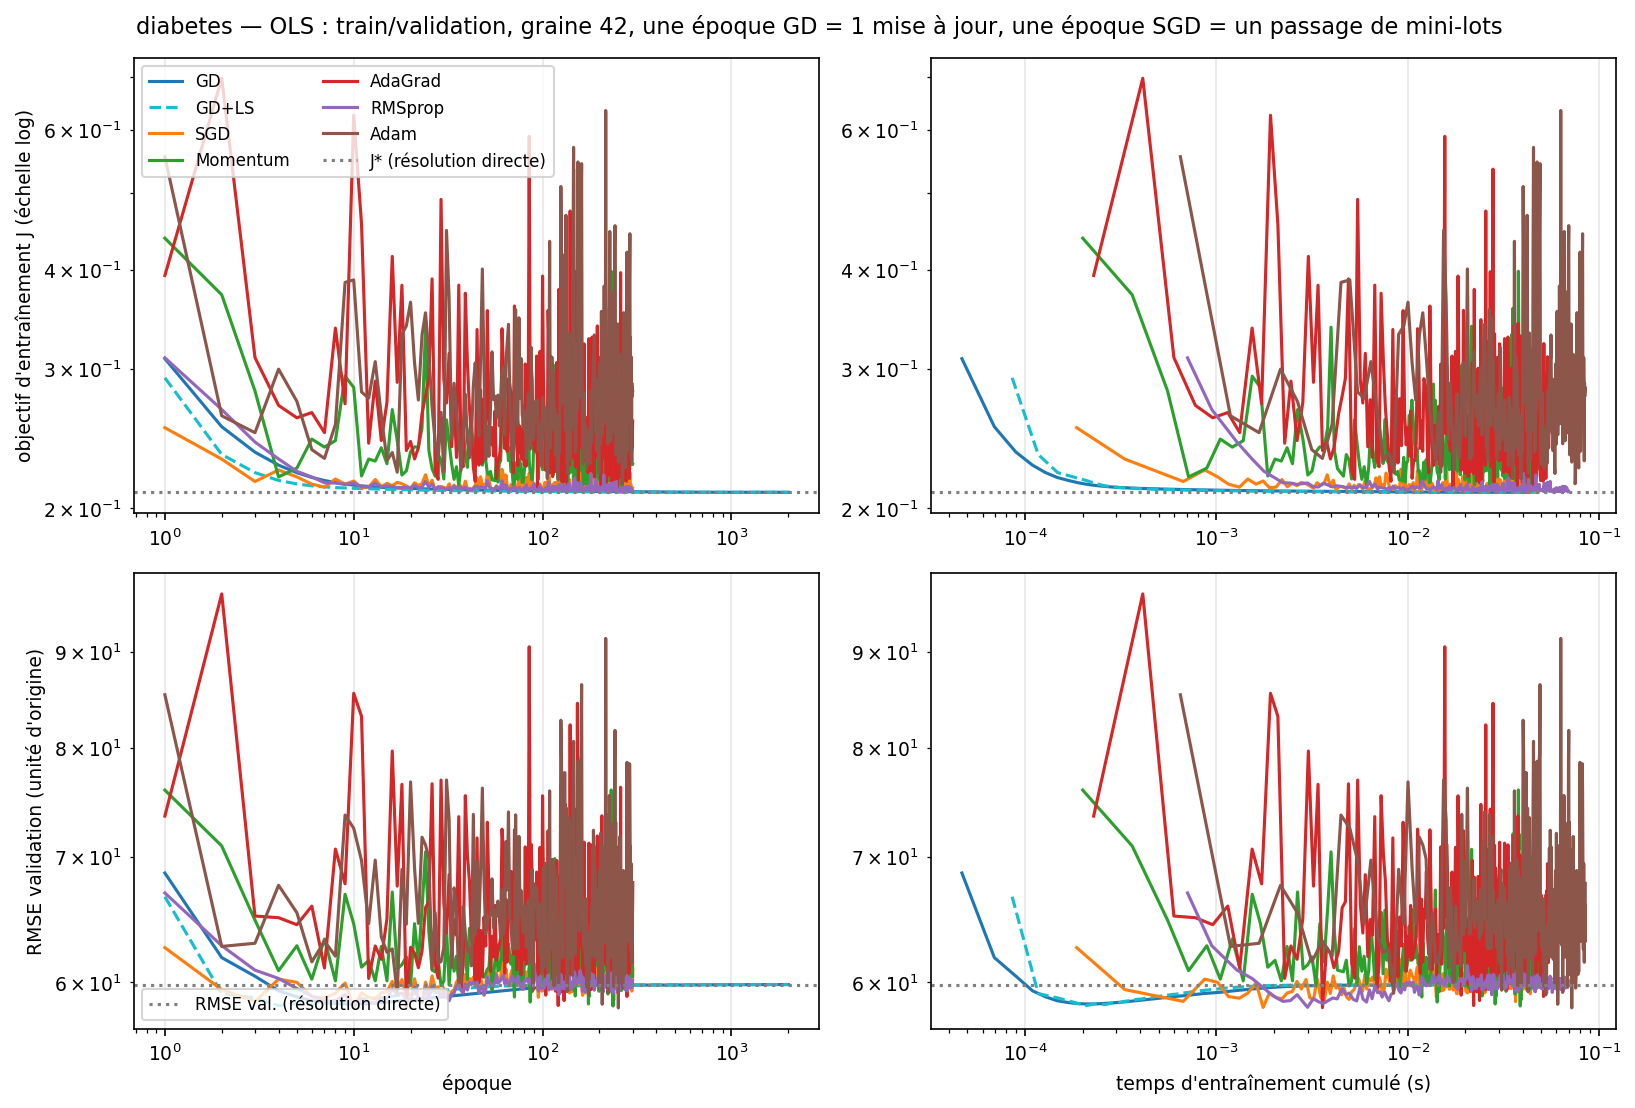

results/full/diabetes/figures/diabetes_Ridge_courbes.png


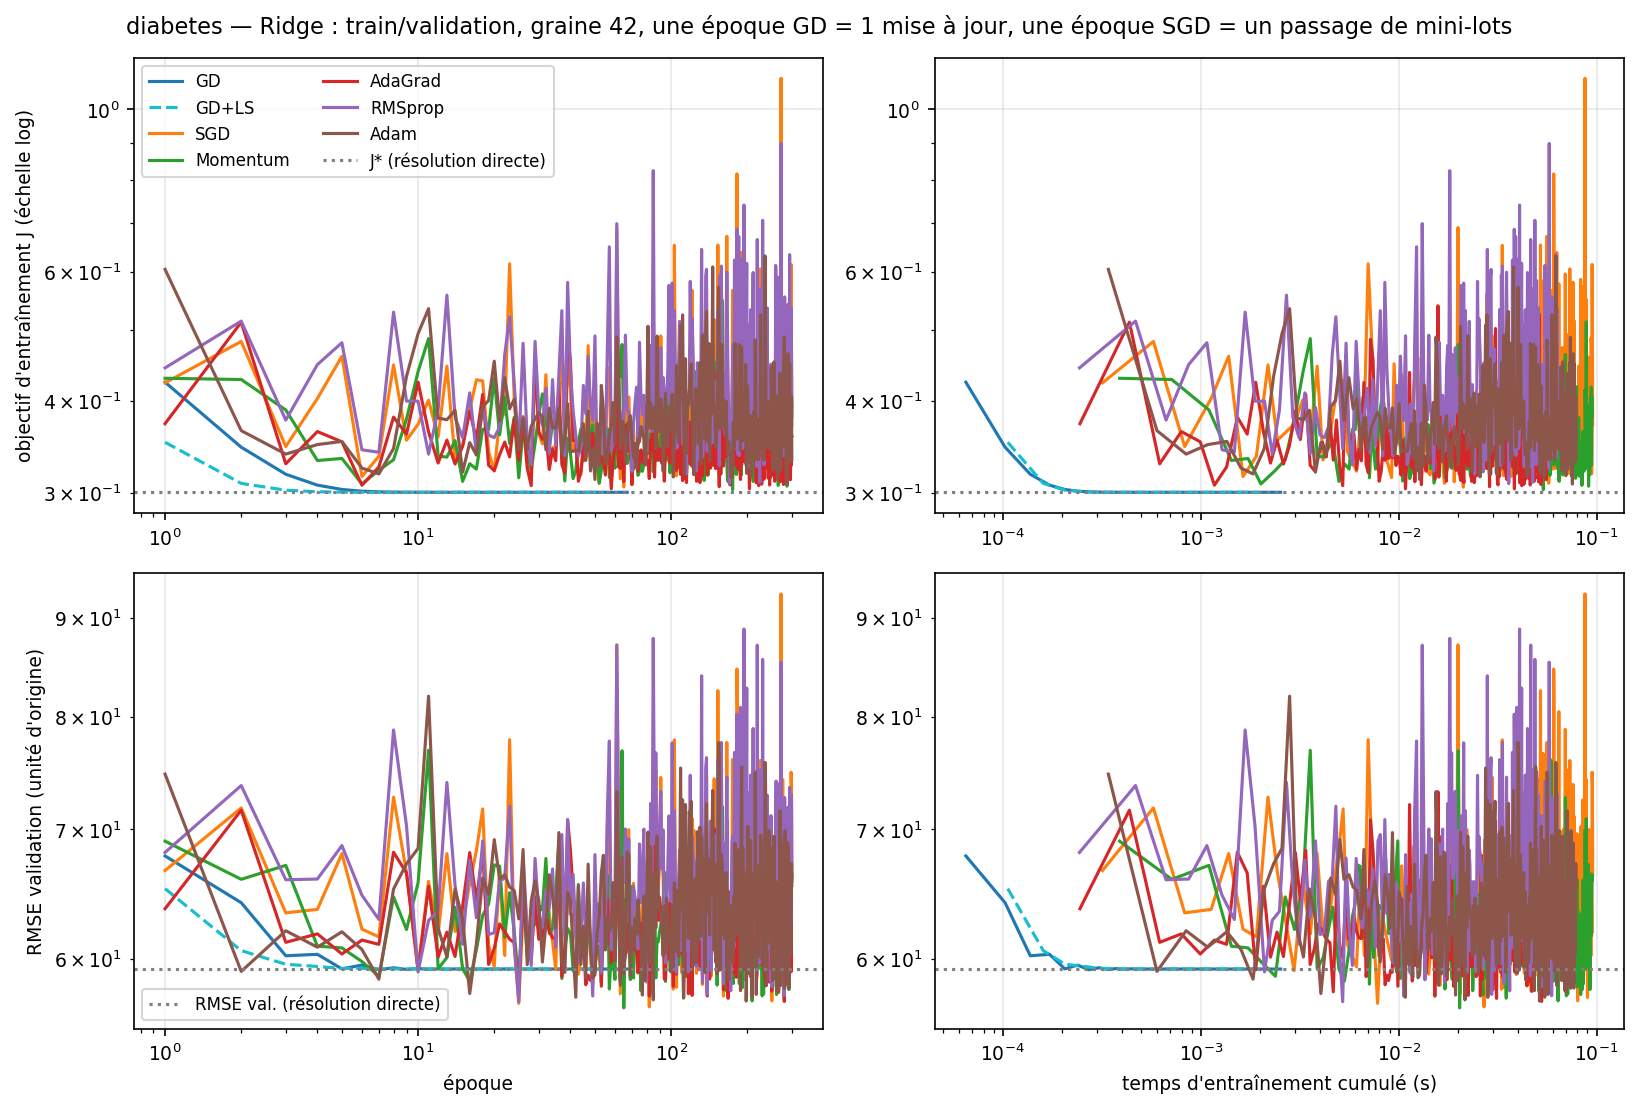

results/full/diabetes/figures/diabetes_correlations.png


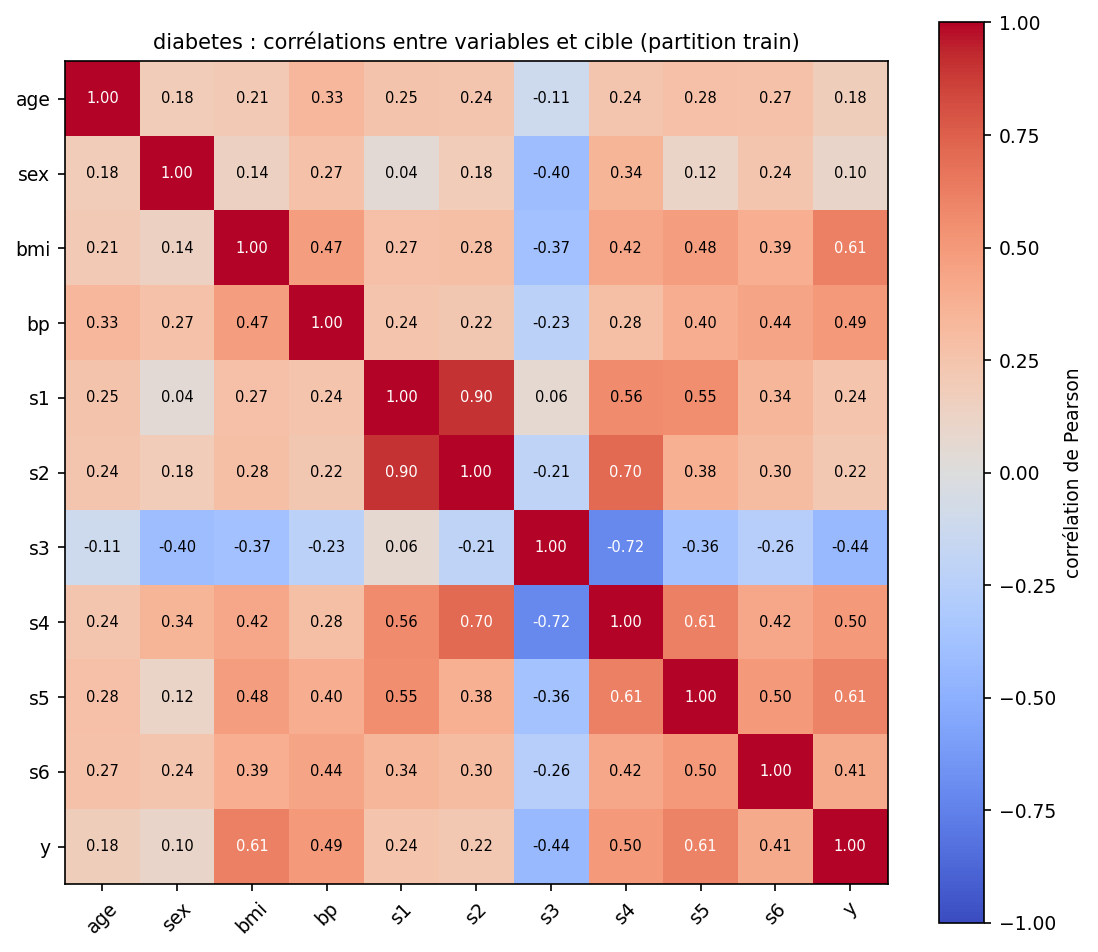

results/full/diabetes/figures/diabetes_predit_vs_reel.png


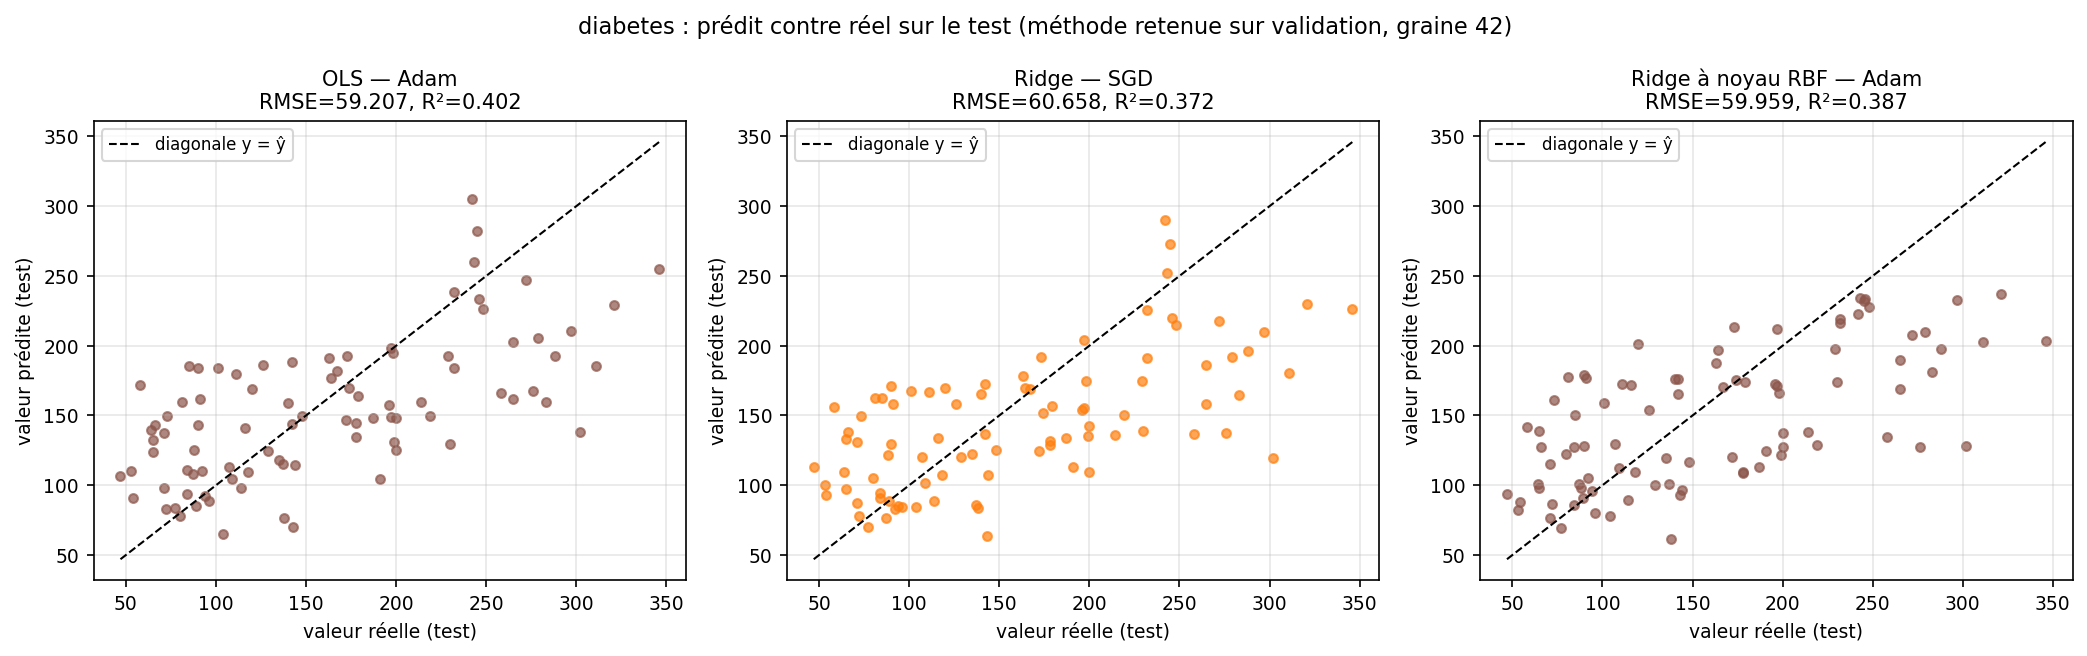

results/full/diabetes/figures/diabetes_residus.png


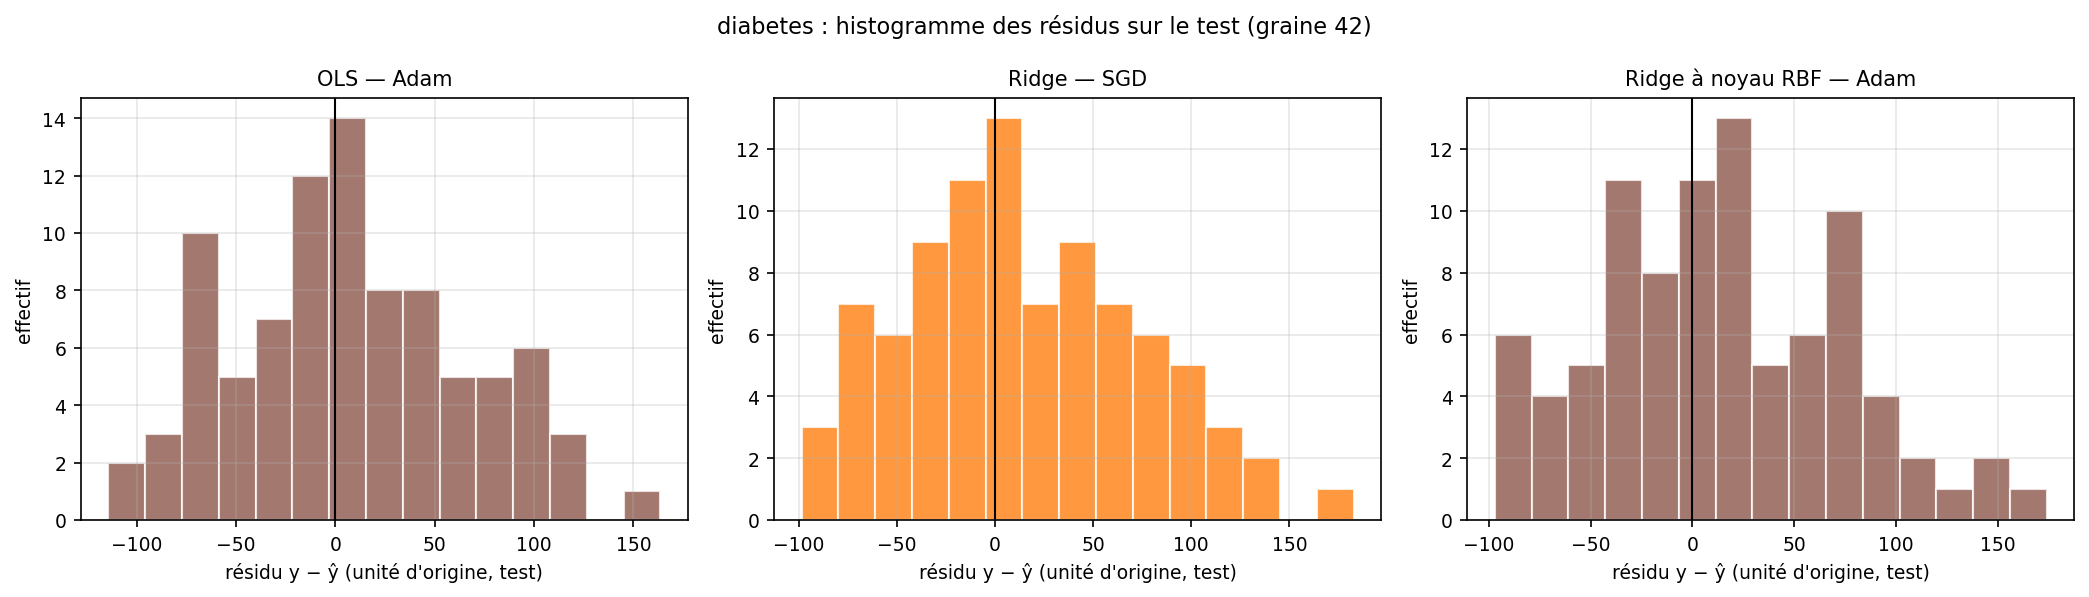

results/full/diabetes/figures/diabetes_rmse_test_par_methode.png


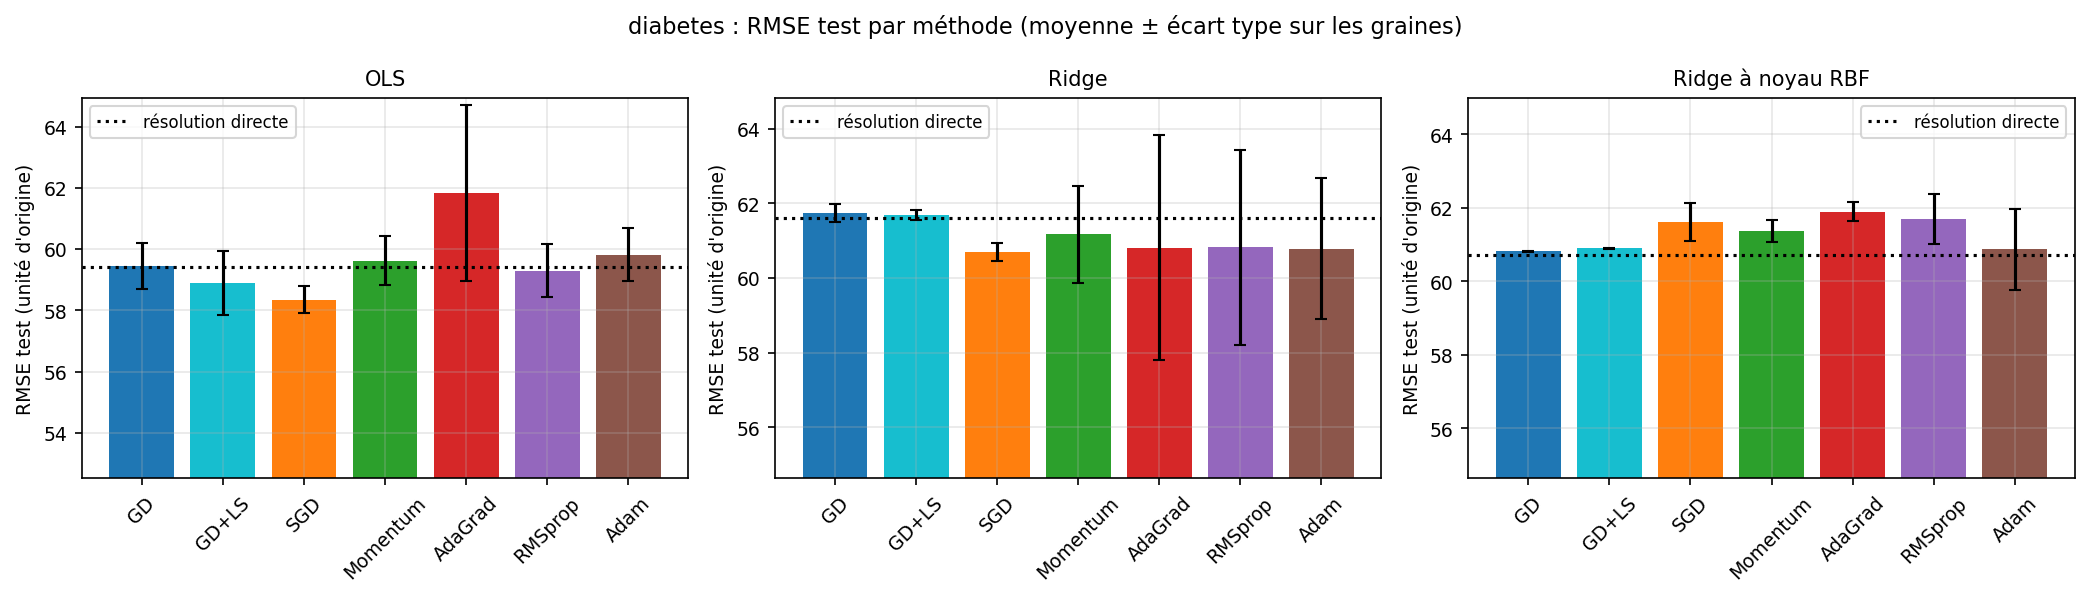

In [15]:
for f in sorted(glob.glob("results/full/diabetes/figures/*.png")):
    print(f); display(Image(f))

## Étape 11 — Sélection des hyperparamètres (λ, σ, η) sur la validation
Le test n'est jamais utilisé pour ces choix.

In [16]:
for ds in ["nonlinear", "diabetes"]:
    print("=====", ds, ": choix de lambda / sigma")
    display(pd.read_csv(f"results/full/{ds}/hyperparameter_selection.csv").head(20))
    print("=====", ds, ": choix de eta par méthode")
    display(pd.read_csv(f"results/full/{ds}/eta_selection.csv").head(30))

===== nonlinear : choix de lambda / sigma


,model,lambda,sigma,val_rmse
0,Ridge,1.000000e-04,NaN,0.734609
1,Ridge,3.162278e-04,NaN,0.734604
2,Ridge,1.000000e-03,NaN,0.734590
3,Ridge,3.162278e-03,NaN,0.734545
4,Ridge,1.000000e-02,NaN,0.734407
5,Ridge,3.162278e-02,NaN,0.734015
6,Ridge,1.000000e-01,NaN,0.733156
7,Ridge,3.162278e-01,NaN,0.732785
8,Ridge,1.000000e+00,NaN,0.737915
9,Ridge,3.162278e+00,NaN,0.749936


===== nonlinear : choix de eta par méthode


,model,method,eta,val_rmse,diverged
0,OLS,GD,0.000100,0.776310,False
1,OLS,GD,0.000316,0.751173,False
2,OLS,GD,0.001000,0.734604,False
3,OLS,GD,0.003162,0.734121,False
4,OLS,GD,0.010000,0.734119,False
5,OLS,GD,0.031623,0.734113,False
6,OLS,GD,0.100000,0.734090,False
7,OLS,GD,0.316228,0.733990,False
8,OLS,GD,1.000000,0.731214,False
9,OLS,GD,3.162278,inf,True


===== diabetes : choix de lambda / sigma


,model,lambda,sigma,val_rmse
0,Ridge,1.000000e-04,NaN,59.825223
1,Ridge,3.162278e-04,NaN,59.814092
2,Ridge,1.000000e-03,NaN,59.782531
3,Ridge,3.162278e-03,NaN,59.704902
4,Ridge,1.000000e-02,NaN,59.533729
5,Ridge,3.162278e-02,NaN,59.162045
6,Ridge,1.000000e-01,NaN,58.575281
7,Ridge,3.162278e-01,NaN,58.222459
8,Ridge,1.000000e+00,NaN,59.298894
9,Ridge,3.162278e+00,NaN,62.899404


===== diabetes : choix de eta par méthode


,model,method,eta,val_rmse,diverged
0,OLS,GD,0.000100,69.953683,False
1,OLS,GD,0.000316,62.654671,False
2,OLS,GD,0.001000,58.786329,False
3,OLS,GD,0.003162,58.444800,False
4,OLS,GD,0.010000,58.444228,False
5,OLS,GD,0.031623,58.442417,False
6,OLS,GD,0.100000,58.436869,False
7,OLS,GD,0.316228,58.420617,False
8,OLS,GD,1.000000,inf,True
9,OLS,GD,3.162278,inf,True


## 12 — Vérification numérique des gradients


In [17]:
for ds in ["nonlinear", "diabetes"]:
    print("=====", ds)
    display(pd.read_csv(f"results/full/{ds}/gradient_check.csv"))

===== nonlinear


,dataset,model,lot,coord,grad_analytique,grad_numerique,erreur_relative
0,nonlinear,OLS,lot complet,0,0.062865,0.062865,5.776397e-11
1,nonlinear,OLS,lot complet,1,-0.015643,-0.015643,6.809943e-10
2,nonlinear,OLS,lot complet,2,0.660803,0.660803,3.013702e-12
3,nonlinear,OLS,mini-lot 32,0,-0.216448,-0.216448,7.314885e-12
4,nonlinear,OLS,mini-lot 32,1,0.300831,0.300831,1.431922e-13
5,nonlinear,OLS,mini-lot 32,2,0.627809,0.627809,6.510751e-12
6,nonlinear,Ridge,lot complet,0,0.062865,0.062865,5.776397e-11
7,nonlinear,Ridge,lot complet,1,-0.224519,-0.224519,4.806454e-11
8,nonlinear,Ridge,lot complet,2,1.673400,1.673400,4.464379e-13
9,nonlinear,Ridge,mini-lot 32,0,-0.216448,-0.216448,7.314885e-12


===== diabetes


,dataset,model,lot,coord,grad_analytique,grad_numerique,erreur_relative
0,diabetes,OLS,lot complet,0,0.062865,0.062865,5.776739e-11
1,diabetes,OLS,lot complet,2,-0.192554,-0.192554,3.842118e-11
2,diabetes,OLS,lot complet,3,-1.168078,-1.168078,3.651991e-12
3,diabetes,OLS,lot complet,4,-1.078449,-1.078449,2.627395e-12
4,diabetes,OLS,lot complet,5,-0.151180,-0.151180,3.958379e-11
5,diabetes,OLS,lot complet,7,1.270657,1.270657,1.174157e-11
6,diabetes,OLS,mini-lot 32,0,0.444544,0.444544,1.283497e-12
7,diabetes,OLS,mini-lot 32,2,0.062106,0.062106,1.503947e-10
8,diabetes,OLS,mini-lot 32,3,-1.537807,-1.537807,6.406966e-12
9,diabetes,OLS,mini-lot 32,4,-1.300006,-1.300006,1.757816e-12
